In [78]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [79]:
from sklearn.datasets import make_classification

In [80]:
X, y = make_classification(
    n_samples=100,
    n_features=2,  # 2D for visualization
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    random_state=42
)

In [81]:
# coordinates
X

array([[ 1.22831184, -0.75717844],
       [ 0.69840909, -1.38029525],
       [ 2.54881729,  2.50225822],
       [ 0.57357881, -1.35297943],
       [ 0.58590018, -1.33745666],
       [ 0.63356167, -1.17278867],
       [ 0.55656344, -1.31038476],
       [ 0.12437227,  0.19896733],
       [ 1.32272135, -0.59340317],
       [ 1.42586898,  1.39002959],
       [ 0.63944087, -1.23395477],
       [ 1.2349949 , -0.73168763],
       [ 0.73902766,  0.82180719],
       [ 2.22140553,  2.10036638],
       [ 3.08402116,  2.83324852],
       [ 1.00183089, -1.02646717],
       [ 1.03307436, -0.85545993],
       [ 0.10320711,  0.21791213],
       [ 0.57885884,  0.56599415],
       [ 1.71073996,  1.56900774],
       [ 1.1586864 , -0.88167436],
       [ 3.07317945,  2.84564176],
       [ 1.88782031, -0.36699364],
       [ 0.48727907,  0.59970882],
       [ 3.07752729,  2.90114736],
       [ 0.22485502,  0.29482153],
       [ 1.12991576,  1.10236134],
       [ 0.85095512, -1.18455216],
       [-0.00832267,

In [82]:
# labels
y

array([0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1,
       0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1])

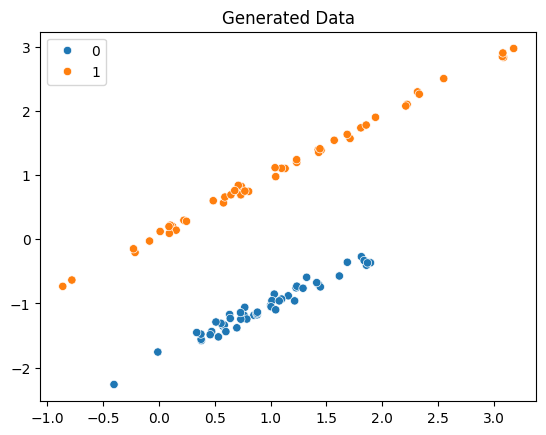

In [83]:
sns.scatterplot(x=X[:,0], y=X[:,1], hue=y)
plt.title("Generated Data")
plt.show()

In [84]:
from sklearn.model_selection import train_test_split

In [85]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [86]:
from sklearn.svm import SVC

In [87]:
model = SVC(kernel='linear')
model.fit(X_train,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


**Understand the Decision Boundary**

The decision boundary (or hyperplane) for a linear Support Vector Classifier is defined by the following linear equation:
$$w_1x_1 + w_2x_2 + b = 0$$

- The Hyperplane: This line acts as the separator between different classes. In higher dimensions, this line becomes a plane or a hyperplane.

- The Goal: The SVC algorithm selects the specific weights ($w$) and bias ($b$) such that the margin (the distance between the hyperplane and the nearest data points of any class, known as support vectors) is maximized.

In [88]:
# prediction

y_pred = model.predict(X_test)

In [89]:
from sklearn.metrics import classification_report, confusion_matrix

In [90]:
cr = classification_report(y_test,y_pred)
print(cr)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       1.00      1.00      1.00         7

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



In [91]:
cm = confusion_matrix(y_test,y_pred)
print(cm)

[[13  0]
 [ 0  7]]


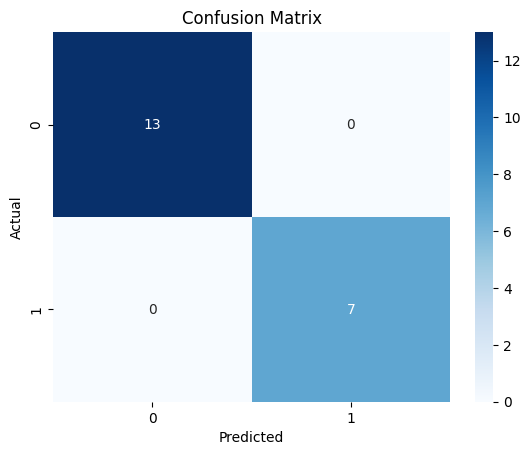

In [92]:
# confusion matrix visualization

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()